This model predicts whether a loan will be approved or rejected using different models, 
manual review of loans are slow, inconsistent and biased.
this model helps to predict which applicant will repay or default

In [2]:
import os
os.getcwd()
os.listdir('Downloads\machine learning datasets')

['1553768847-housing.csv',
 'archive (10).zip',
 'Churn_Modelling.csv',
 'combined_data.csv',
 'customer_churn_dataset',
 'customer_churn_dataset-testing-master.csv',
 'customer_churn_dataset-training-master.csv',
 'customer_churn_dataset.csv',
 'diabetes_prediction_dataset.csv',
 'loanapproval.csv',
 'loan_approval.csv',
 'loan_approval_dataset.csv',
 'loan_data.csv',
 'loan_sanction_test.csv',
 'loan_sanction_train.csv',
 'mail_data.csv',
 'movies.csv',
 'ratings.csv',
 'rent.csv',
 'rent_2.csv',
 'sale.csv',
 'sale_2.csv',
 'spam mail.csv',
 'spam.csv',
 'spam_assassin.csv',
 'spam_or_not_spam.csv']

In [3]:
os.getcwd()

'C:\\Users\\USER'

Import Libraries and Packages

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, recall_score)

Load dataset

In [5]:
loan_df = pd.read_csv('C:\\Users\\USER\Downloads\machine learning datasets\loan_approval_dataset.csv')

first five rows

In [6]:
loan_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Last five rows

In [7]:
loan_df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [8]:
loan_df.shape

(4269, 13)

In [9]:
loan_df.size

55497

In [10]:
print('Number of missing Values in each Column:', loan_df.isna().sum())

Number of missing Values in each Column: loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


Columns Present in the Dataset

In [11]:
for columns in loan_df:
    print(columns)

loan_id
 no_of_dependents
 education
 self_employed
 income_annum
 loan_amount
 loan_term
 cibil_score
 residential_assets_value
 commercial_assets_value
 luxury_assets_value
 bank_asset_value
 loan_status


Statistical Description of Numerical Columns

In [12]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


Dataset information Which includes Data types, numbers of null Values

In [13]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


Remove spaces in  column names

In [14]:
loan_df.columns = loan_df.columns.str.strip().str.replace('', "")

In [15]:
loan_df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

Columns with Numerical Values

In [16]:
numeric_col =loan_df.select_dtypes(include='int64')

numeric_col

Column with categorical data or object as data types

In [18]:
categorical_col = loan_df.select_dtypes(include='object')

In [19]:
categorical_col

,education,self_employed,loan_status
0,Graduate,No,Approved
1,Not Graduate,Yes,Rejected
2,Graduate,No,Rejected
3,Graduate,No,Rejected
4,Not Graduate,Yes,Rejected
...,...,...,...
4264,Graduate,Yes,Rejected
4265,Not Graduate,Yes,Approved
4266,Not Graduate,No,Rejected
4267,Not Graduate,No,Approved


In [20]:
print(' Number of Duplicates:', loan_df.duplicated().sum())

 Number of Duplicates: 0


Drop Loan_id as it is irrelevant to the model

In [21]:
loan_df.drop(columns='loan_id', axis=1).head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Numbers of Each unique Value in Our Target Variable

In [22]:
loan_df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [23]:
loan_df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [24]:
loan_df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [25]:
loan_df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [26]:
status = loan_df['loan_status'].value_counts()

A visual representation of the Percenatges of each values in A categorical column

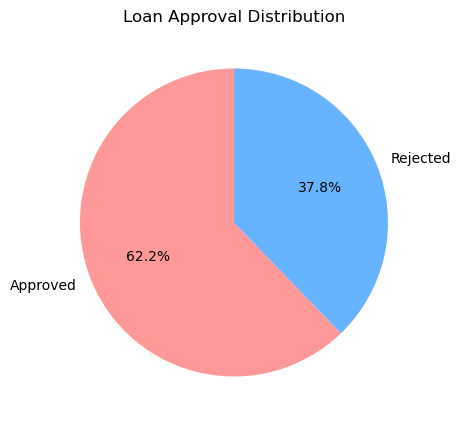

In [27]:
plt.figure(figsize=(5,5))
status.plot.pie(autopct='%1.1f%%', labels=['Approved', 'Rejected'], colors=['#ff9999', '#66b3ff'], startangle=90)
plt.title('Loan Approval Distribution')
plt.ylabel('')
plt.show()

In [28]:
education=loan_df['education'].value_counts()

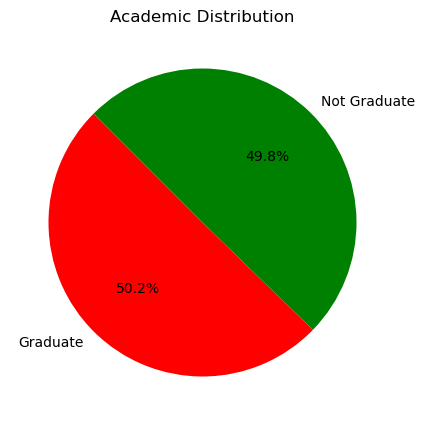

In [29]:
plt.figure(figsize=(5,5))
education.plot.pie(autopct='%1.1f%%', labels=['Graduate', 'Not Graduate'], colors=['red', 'green'], startangle=135)
plt.title('Academic Distribution')
plt.ylabel('')
plt.show()

In [30]:
selfemployed=loan_df['self_employed'].value_counts()

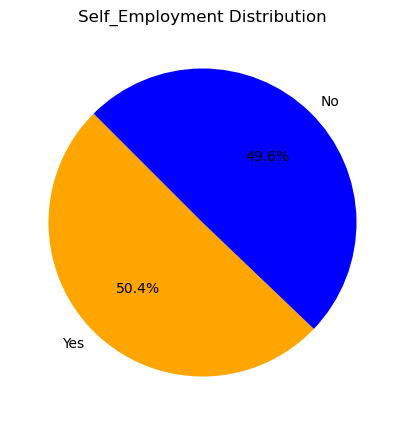

In [31]:
plt.figure(figsize=(5,5))
selfemployed.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], colors=['orange', 'blue'], startangle=135)
plt.title('Self_Employment Distribution')
plt.ylabel('')
plt.show()

Histogram Shows the Dristribution of Numerical Variables and Columns, identify skewed or Normal distribution

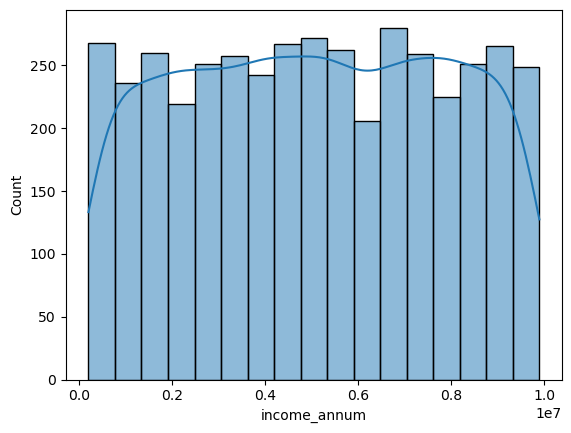

In [32]:
sns.histplot(x=loan_df['income_annum'], data=loan_df, kde=True)
plt.show()

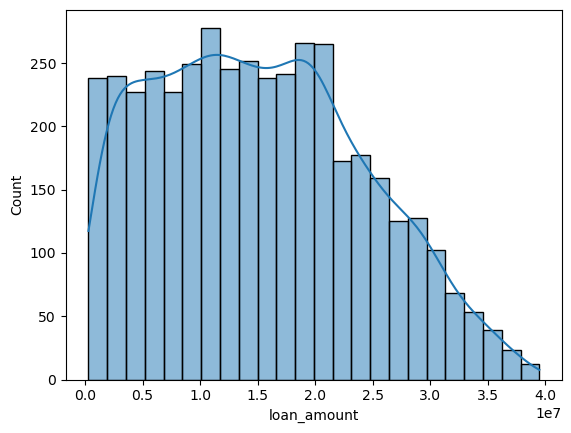

In [33]:
sns.histplot(x=loan_df['loan_amount'], data=loan_df, kde=True)
plt.show()

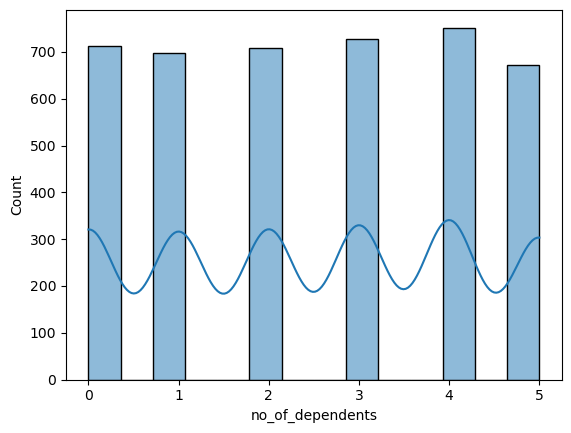

In [34]:
sns.histplot(x=loan_df['no_of_dependents'], data=loan_df, kde=True)
plt.show()

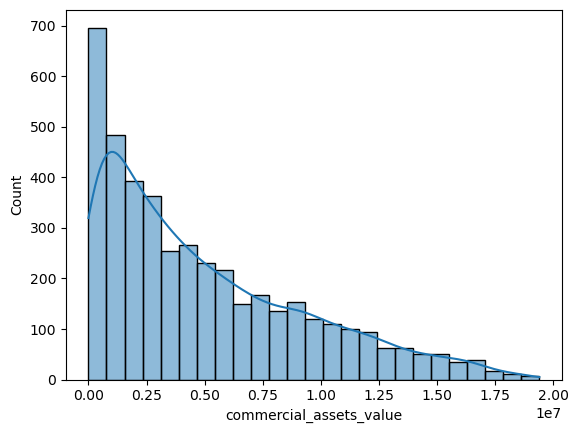

In [35]:
sns.histplot(x=loan_df['commercial_assets_value'], data=loan_df, kde=True)
plt.show()

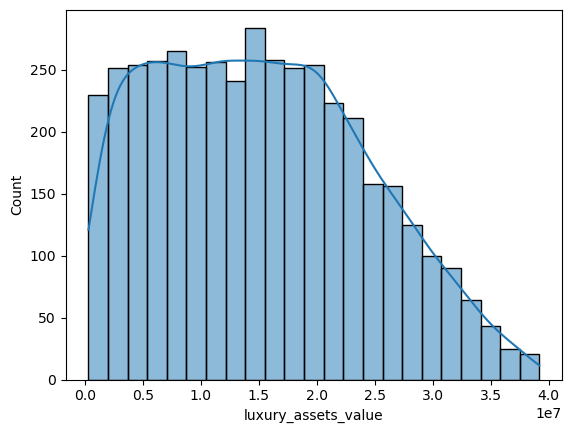

In [36]:
sns.histplot(x=loan_df['luxury_assets_value'], data=loan_df, kde=True)
plt.show()

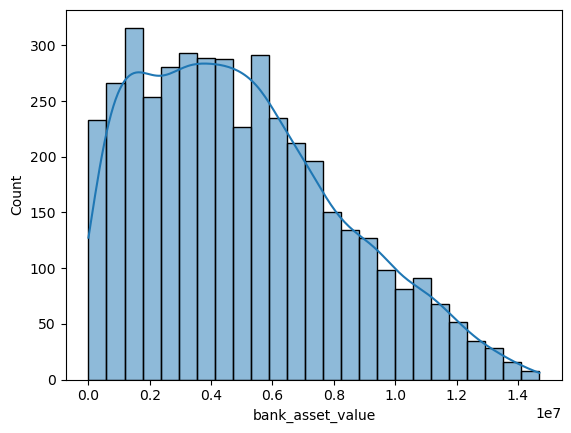

In [37]:
sns.histplot(x=loan_df['bank_asset_value'], data=loan_df, kde=True)
plt.show()

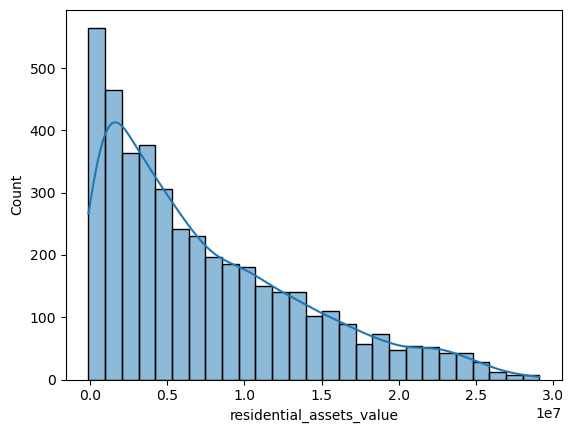

In [38]:
sns.histplot(x=loan_df['residential_assets_value'], data=loan_df, kde=True)
plt.show()

In [39]:
numeric_col

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [40]:
loan_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [41]:
loan_df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [42]:
loan_df['loan_status'] = loan_df['loan_status'].str.strip()

In [43]:
loan_df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

Encoding Categorical Columns Manually Using Map

In [44]:
loan_df['loan_status'] = loan_df['loan_status'].map({'Approved':1, 'Rejected':0})

In [45]:
loan_df['loan_status']

0       1
1       0
2       0
3       0
4       0
       ..
4264    0
4265    1
4266    0
4267    1
4268    1
Name: loan_status, Length: 4269, dtype: int64

In [46]:
loan_df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

Removing Spaces in Column

In [47]:
loan_df['education'] =loan_df['education'].str.strip()

In [48]:
loan_df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [49]:
loan_df['education'] = loan_df['education'].map({'Graduate':1, 'Not Graduate':0})

In [50]:
loan_df['education']

0       1
1       0
2       1
3       1
4       0
       ..
4264    1
4265    0
4266    0
4267    0
4268    1
Name: education, Length: 4269, dtype: int64

In [51]:
loan_df['self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [52]:
loan_df['self_employed'] = loan_df['self_employed'].str.strip()

In [53]:
loan_df['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [54]:
loan_df['self_employed'] = loan_df['self_employed'].map({'Yes':1, 'No':0})

Loan Dataset With complete Encoding of Binary Categorical Columns

In [55]:
loan_df.head(4)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0


Dropping Loan_id

In [56]:
X = loan_df.drop(['loan_id', 'loan_status'], axis=1)

Our Id has been dropped 

In [57]:
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [58]:
y = loan_df['loan_status']

In [59]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

Numbers of Approved and Rejected Loans Each

In [60]:
y.value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

Split the Loan Dataset into Training set and Testing sets, with X_train for training, and X_test to validate our model, we use 30% of our data for testing and 70% for training

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Shape of data after splitting

In [62]:
X_train.shape

(2988, 11)

In [63]:
X_test.shape

(1281, 11)

In [64]:
y_train.shape

(2988,)

In [65]:
y_test.shape

(1281,)

For this Project i made use of Logistic Regression as my Baseline Model, without feature transformation or feature scaling

In [66]:
LogR = LogisticRegression(max_iter=1000)

In [67]:
model = LogR.fit(X_train, y_train)

In [68]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [69]:
y_train_pred = model.predict(X_train)

In [70]:
y_test_pred = model.predict(X_test)

Train and Test Accuracy using Logistic Regression Model

In [71]:
print('Accuracy', accuracy_score(y_train, y_train_pred))

Accuracy 0.7958500669344043


In [72]:
print('Accuracy', accuracy_score(y_test, y_test_pred))

Accuracy 0.7970335675253708


In [73]:
print(confusion_matrix(y_test, y_test_pred))

[[281 190]
 [ 70 740]]


In [74]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.60      0.68       471
           1       0.80      0.91      0.85       810

    accuracy                           0.80      1281
   macro avg       0.80      0.76      0.77      1281
weighted avg       0.80      0.80      0.79      1281



The model gave an accuracy of 80% for both training and testing data, so our model is generalising fine without any overfitting

from our confusion matrix there is a Class imbalance as the model is biased towards class 1 810 VS 471, our model predicted correctly 281 approved loans, 740 rejected loans were predicted correctly, while the model also approved 190 loans instead of rejecting them, in a finacial institution, this can lead to loss as defaulters won't pay back, the model rejected 70 customers who were supposed to be granted loan (loss of profits)

Precision for approved is 80% which means 80% of the time the model predicted approved loan correctly, while for Rejected the recall is lesser (60%) so basically the model is missing 40% of the rejected loan, this corresponds to the 190 false positives.
we will have to reduce the false positives as 190 approved loans instead of rejected is a risk

To Improve the performace of our Model we are going to peform some feature engineering 

In [75]:
X_train.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3404,4,0,0,2800000,8300000,14,381,3200000,1100000,9100000,1500000
781,3,0,1,9900000,20400000,4,865,26300000,3600000,36500000,12800000
3002,4,1,1,3500000,10700000,8,883,200000,2300000,8400000,2000000
4047,3,0,0,6400000,23000000,8,520,12100000,11400000,16000000,3800000
3391,2,1,1,3300000,6700000,8,845,1300000,4600000,12300000,3200000


In [76]:
X_train.skew()

no_of_dependents            0.027206
education                  -0.014733
self_employed              -0.029469
income_annum               -0.026393
loan_amount                 0.290417
loan_term                   0.022310
cibil_score                -0.016232
residential_assets_value    1.014669
commercial_assets_value     0.961329
luxury_assets_value         0.307668
bank_asset_value            0.543869
dtype: float64

These columns are right skewed from the data distribution of the Histogram, residential_assets_value, commercial_assets_value, are right skewed as abunch of the data are clustered at the left-hand side of the distribution, while the tail stretches towards the right, most people are poor , few people are rich.

In [77]:
extreme_cols =['residential_assets_value', 'commercial_assets_value']

In [78]:
X_train[extreme_cols] = X_train[extreme_cols].clip(lower=0)

In [79]:
X_test[extreme_cols] = X_test[extreme_cols].clip(lower=0)

In [80]:
X_train[extreme_cols]

,residential_assets_value,commercial_assets_value
3404,3200000,1100000
781,26300000,3600000
3002,200000,2300000
4047,12100000,11400000
3391,1300000,4600000
...,...,...
3444,3200000,1000000
466,1000000,500000
3092,10800000,10600000
3772,3700000,1300000


In [81]:
X_train['residential_assets_value'].isna().sum()

np.int64(0)

logistic regression is a distanced based model and as such we have to transform our skewed data and also scale it, so as to prevent values with large magnitude from dominating the model. in this case i am using standard scaler

In [82]:
log_col = ['residential_assets_value', 'commercial_assets_value', 'bank_asset_value']

In [83]:
scale_col = ['luxury_assets_value', 'income_annum',  'loan_amount', 'cibil_score']

To prevent data leakage, and code reproductibility i will be using a pipeline

In [84]:
log_pipe = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

In [85]:
scale_pipe = Pipeline([
    ('scale',  StandardScaler())
])

so we have log transformed and scaled our numerical columns which are right skewed

In [86]:
preprocessor = ColumnTransformer(transformers=[('log_pipe', log_pipe, log_col), ('scale_pipe', scale_pipe, scale_col)])

In [87]:
preprocessor

,transformers,"[('log_pipe', ...), ('scale_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False


Applying Logistic Regression after feature preprocessing

In [88]:
clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [89]:
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log_pipe', ...), ('scale_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
y_pred =clf.predict(X_train)

In [91]:
print('Accuracy', accuracy_score(y_train, y_pred))

Accuracy 0.9240294511378849


In [92]:
y_pred =clf.predict(X_test)
print('Accuracy', accuracy_score(y_test, y_pred))

Accuracy 0.9188134270101483


In [93]:
print(confusion_matrix(y_test, y_pred))

[[431  40]
 [ 64 746]]


In [94]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89       471
           1       0.95      0.92      0.93       810

    accuracy                           0.92      1281
   macro avg       0.91      0.92      0.91      1281
weighted avg       0.92      0.92      0.92      1281



Boom!!!!, our false positives dropped from 190 to 40 after log transformation and scaling (feature preprocessing),  and the False negavties also dropped from 70 to 64. this is great  improvement on our model after feature preprocessing
431 loans were rejected correctly, 746 loans were approved correctly, the model rejected 40 loans instead of approving  them, while 64 approved  loans were rejected instead of being approved. 
95% precision on the approved class and 87% precision on the rejected class.
92% accuracy is great
40 FP and 64 FN still poses high financial risks

Using Random Forest

In [95]:
Rfc= Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=5))
])

In [96]:
Rfc.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log_pipe', ...), ('scale_pipe', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
y_pred_2 = Rfc.predict(X_train)

In [98]:
print('Accuracy', accuracy_score(y_train, y_pred_2))

Accuracy 0.9558232931726908


In [99]:
y_pred_2 = Rfc.predict(X_test)

In [100]:
print('Accuracy', accuracy_score(y_test, y_pred_2))

Accuracy 0.9492583918813428


In [101]:
print(confusion_matrix(y_test, y_pred_2))

[[468   3]
 [ 62 748]]


In [102]:
print(classification_report(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.88      0.99      0.94       471
           1       1.00      0.92      0.96       810

    accuracy                           0.95      1281
   macro avg       0.94      0.96      0.95      1281
weighted avg       0.95      0.95      0.95      1281



Decision Tree gave a massive upgrade, only 3 loans were wrongly approved, this is an improvement from 40, 62 good loans were rejected, this is virtually unchanged from 64. so we have eradicated the risk of approving 40 rejected loans.

In [103]:
Xgb= XGBClassifier(n_estimators=200, random_state=42, max_depth=6, subsample=0.8, learning_rate=0.1, eval_metric='logloss')

In [104]:
Xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [105]:
y_pred_xgb = Xgb.predict(X_train)

In [106]:
print('Accuracy for test data:', accuracy_score(y_train, y_pred_xgb))

Accuracy for test data: 1.0


In [107]:
y_pred_xgb = Xgb.predict(X_test)

In [108]:
print('Accuracy for test data:', accuracy_score(y_test, y_pred_xgb))

Accuracy for test data: 0.975800156128025


In [109]:
print(confusion_matrix(y_test, y_pred_xgb))

[[454  17]
 [ 14 796]]


In [110]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       471
           1       0.98      0.98      0.98       810

    accuracy                           0.98      1281
   macro avg       0.97      0.97      0.97      1281
weighted avg       0.98      0.98      0.98      1281



XGBoost beats both Logistic Regression and Random forest.
FP from 3 to 17 , FN from 62 went down to 14.
what this means is that, 17 bad loans were approved, while 14 good laons were rejected.

so here is the delima, will you rather go for a model that approves 17 bad loans and rejects 14 good loans, or one that approves 3 bad loans while rejecting 62 good loans.

which is worse depends on money.

In [111]:
scores = cross_val_score(Xgb, X, y, cv=5, scoring='accuracy')

In [112]:
print('Scores:', scores)
print('Mean:', scores.mean())
print('Std:', scores.std()) 

Scores: [0.98126464 0.98360656 0.98360656 0.9824356  0.98241501]
Mean: 0.9826656709615602
Std: 0.000877404989886868


In [113]:
models ={'Logistic Regression':LogisticRegression(max_iter=1000),
         'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, min_samples_leaf=5),
         'XGBoost': XGBClassifier(n_estimators=200, random_state=42, max_depth=6, subsample=0.8, learning_rate=0.1, eval_metric='logloss')}

In [114]:
results= []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    results.append({
        'Model': name,
        'Train Accuracy': f'{train_acc:.4f}',
        'Test Accuracy': f'{test_acc:.4f}',
        'CV Mean': f'{cv_mean:.4f}',
        'CV std': f'{cv_std:.4f}'
    })

In [115]:
df_results = pd.DataFrame(results)

In [116]:
print(df_results.to_string(index=False))

              Model Train Accuracy Test Accuracy CV Mean CV std
Logistic Regression         0.7959        0.7970  0.7953 0.0155
      Random Forest         0.9946        0.9742  0.9789 0.0022
            XGBoost         1.0000        0.9758  0.9827 0.0009


In [117]:
results= []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    recall = recall_score(y_test, y_pred)
    TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    results.append({
        'Model': name,
        'Train Accuracy': f'{train_acc:.4f}',
        'Test Accuracy': f'{test_acc:.4f}',
        'CV Mean': f'{cv_mean:.4f}',
        'Recall': f'{recall:.4f}',
        'False Positives': FP,
        'CV std': f'{cv_std:.4f}'
    })

In [118]:
df_results = pd.DataFrame(results)

In [119]:
print(df_results.to_string(index=False))

              Model Train Accuracy Test Accuracy CV Mean Recall  False Positives CV std
Logistic Regression         0.7959        0.7970  0.7953 0.9210               40 0.0155
      Random Forest         0.9946        0.9742  0.9789 0.9210               40 0.0022
            XGBoost         1.0000        0.9758  0.9827 0.9210               40 0.0009
